In [7]:
import pandas as pd 
df = pd.read_csv("annex2.CSV")

In [8]:
df.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No


In [9]:
df.shape

(878503, 7)

In [10]:
df.columns

Index(['Date', 'Time', 'Item Code', 'Quantity Sold (kilo)',
       'Unit Selling Price (RMB/kg)', 'Sale or Return', 'Discount (Yes/No)'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Date                         878503 non-null  object 
 1   Time                         878503 non-null  object 
 2   Item Code                    878503 non-null  int64  
 3   Quantity Sold (kilo)         878503 non-null  float64
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64
 5   Sale or Return               878503 non-null  object 
 6   Discount (Yes/No)            878503 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 46.9+ MB


In [12]:
df.isnull().sum()

Date                           0
Time                           0
Item Code                      0
Quantity Sold (kilo)           0
Unit Selling Price (RMB/kg)    0
Sale or Return                 0
Discount (Yes/No)              0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df["Total"] = df["Quantity Sold (kilo)"] * df["Unit Selling Price (RMB/kg)"]

In [18]:
df[["Quantity Sold (kilo)", "Unit Selling Price (RMB/kg)", "Total"]].head()

,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Total
0,0.396,7.6,3.0096
1,0.849,3.2,2.7168
2,0.409,7.6,3.1084
3,0.421,10.0,4.2100
4,0.539,8.0,4.3120


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Date                         878503 non-null  datetime64[ns]
 1   Time                         878503 non-null  object        
 2   Item Code                    878503 non-null  int64         
 3   Quantity Sold (kilo)         878503 non-null  float64       
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64       
 5   Sale or Return               878503 non-null  object        
 6   Discount (Yes/No)            878503 non-null  object        
 7   Total                        878503 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 53.6+ MB


In [20]:
print(df["Sale or Return"].value_counts())
print(df["Discount (Yes/No)"].value_counts())

Sale or Return
sale      878042
return       461
Name: count, dtype: int64
Discount (Yes/No)
No     831137
Yes     47366
Name: count, dtype: int64


In [21]:
df["Total"].sum()

np.float64(3369766.4768000003)

In [22]:
df["Total"].mean()

np.float64(3.8358053151782068)

In [23]:
df.groupby("Sale or Return")["Total"].sum()

Sale or Return
return   -2.256865e+03
sale      3.372023e+06
Name: Total, dtype: float64

In [24]:
df.groupby("Discount (Yes/No)")["Total"].sum()

Discount (Yes/No)
No     3.208647e+06
Yes    1.611191e+05
Name: Total, dtype: float64

In [25]:
df.groupby("Item Code")["Total"].sum().sort_values(ascending=False).head(10)

Item Code
102900005116714    269874.2472
102900005116899    211652.1013
102900005116530    211198.3864
102900011016701    205113.6991
102900005115779    129756.9615
102900005116257    117729.4239
102900005117056     95568.6339
102900011000328     82009.3451
102900005115984     70665.1061
102900011021842     64339.6000
Name: Total, dtype: float64

In [26]:
daily_sales = df.groupby("Date")["Total"].sum()
daily_sales.head()

Date
2020-07-01    3472.0136
2020-07-02    3456.5429
2020-07-03    3384.7701
2020-07-04    4394.8624
2020-07-05    4471.5748
Name: Total, dtype: float64

In [27]:
daily_sales.describe()

count     1085.000000
mean      3105.775555
std       1762.907910
min        252.733800
25%       2088.863000
50%       2773.626500
75%       3691.755000
max      28736.506800
Name: Total, dtype: float64

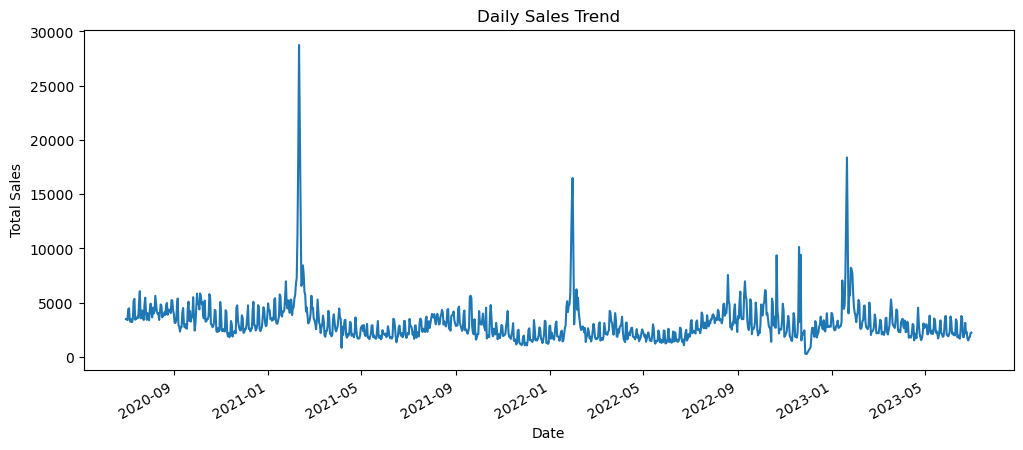

In [28]:
import matplotlib.pyplot as plt

daily_sales.plot(figsize=(12,5))

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [29]:

monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total"].sum()

monthly_sales.head()

Date
2020-07    122550.2935
2020-08    133930.3319
2020-09    106520.8334
2020-10    122685.2828
2020-11     84574.6920
Freq: M, Name: Total, dtype: float64

In [30]:
monthly_sales.describe()

count        36.000000
mean      93604.624356
std       29086.834152
min       52933.362500
25%       74289.174500
50%       87955.605600
75%      112761.467950
max      178817.904000
Name: Total, dtype: float64

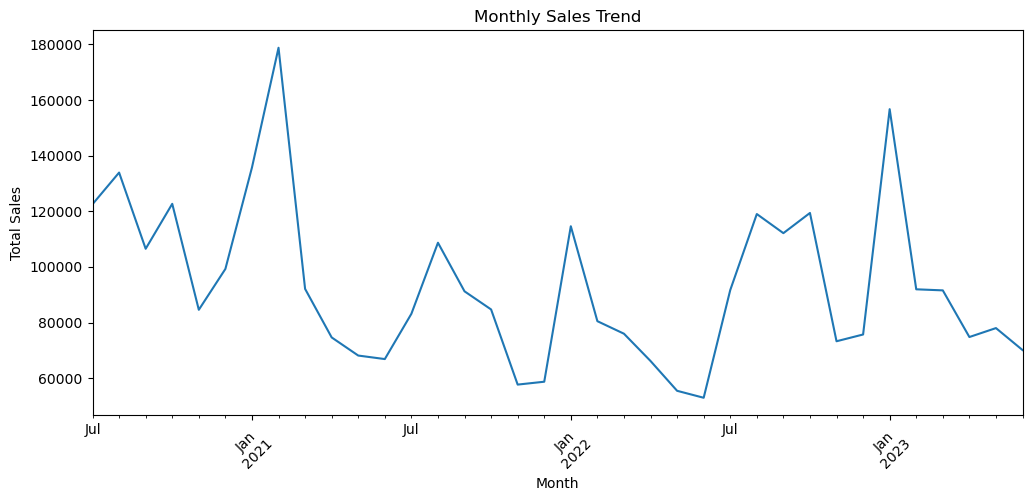

In [31]:
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [32]:
best_month = monthly_sales.idxmax()
best_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_sales = monthly_sales.min()

print("Best Month:", best_month)
print("Best Month Sales:", best_sales)

print("Worst Month:", worst_month)
print("Worst Month Sales:", worst_sales)

Best Month: 2021-02
Best Month Sales: 178817.904
Worst Month: 2022-06
Worst Month Sales: 52933.3625


In [33]:
top_quantity = df.groupby("Item Code")["Quantity Sold (kilo)"].sum().sort_values(ascending=False).head(10)

top_quantity

Item Code
102900011016701    28164.331
102900005116714    27537.228
102900005116899    27149.440
102900005115960    19187.218
102900005115779    15910.461
106949711300259    15596.000
102900011030059    14325.000
102900005116257    13602.001
102900005116530    11920.227
102900011031100    10833.000
Name: Quantity Sold (kilo), dtype: float64

In [34]:
top_quantity = df.groupby("Item Code")["Quantity Sold (kilo)"].sum().sort_values(ascending=False).head(10)

top_quantity

Item Code
102900011016701    28164.331
102900005116714    27537.228
102900005116899    27149.440
102900005115960    19187.218
102900005115779    15910.461
106949711300259    15596.000
102900011030059    14325.000
102900005116257    13602.001
102900005116530    11920.227
102900011031100    10833.000
Name: Quantity Sold (kilo), dtype: float64

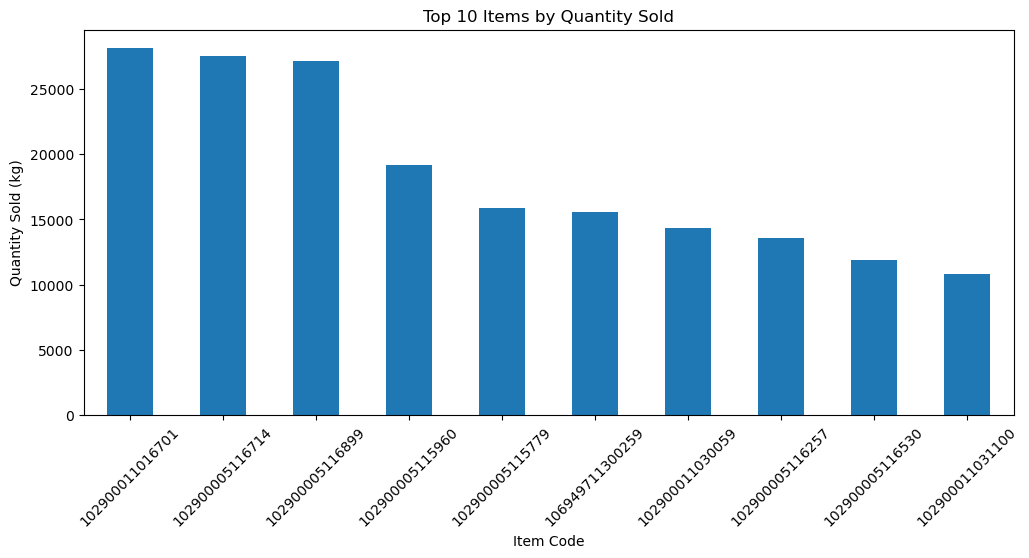

In [35]:
top_quantity.plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Items by Quantity Sold")
plt.xlabel("Item Code")
plt.ylabel("Quantity Sold (kg)")
plt.xticks(rotation=45)
plt.show()

In [36]:
discount_analysis = df.groupby("Discount (Yes/No)")["Total"].agg(["sum", "mean", "count"])

discount_analysis

,sum,mean,count
Discount (Yes/No),,,
No,3.208647e+06,3.860552,831137
Yes,1.611191e+05,3.401578,47366


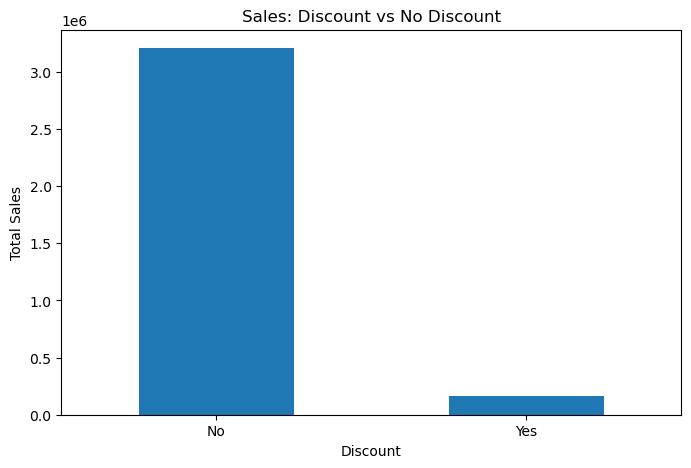

In [37]:
discount_analysis["sum"].plot(kind="bar", figsize=(8,5))

plt.title("Sales: Discount vs No Discount")
plt.xlabel("Discount")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [41]:
df["Time"].head(10)

0    09:15:07.924
1    09:17:27.295
2    09:17:33.905
3    09:19:45.450
4    09:20:23.686
5    09:21:55.556
6    09:21:56.536
7    09:22:01.274
8    09:22:01.476
9    09:22:15.998
Name: Time, dtype: object

In [46]:
df["Hour"] = df["Time"].astype(str).str.split(":").str[0].astype(int)

In [47]:
hourly_sales = df.groupby("Hour")["Total"].sum()
hourly_sales

Hour
8          3.9100
9     281576.2236
10    468435.9647
11    368073.0002
12    192757.2675
13    142793.4691
14    169146.4412
15    247113.3161
16    320312.6801
17    352750.6960
18    331021.0683
19    230216.0899
20    196319.3147
21     68298.7531
22       950.1903
23        -1.9080
Name: Total, dtype: float64

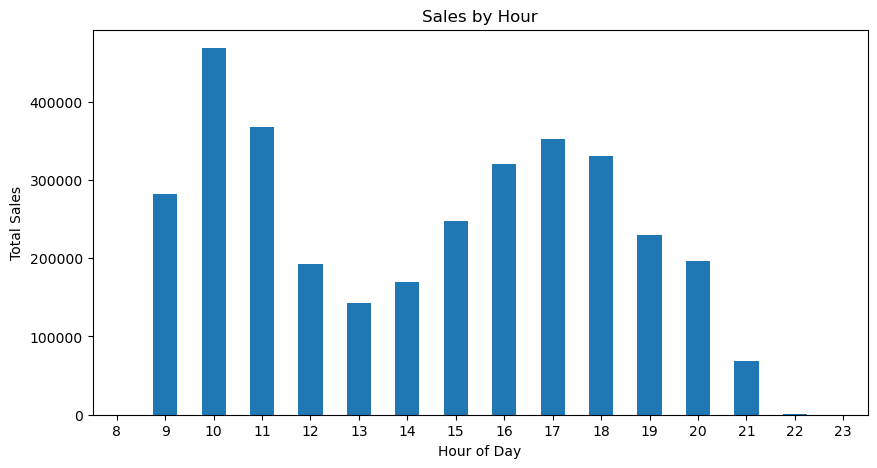

In [48]:
hourly_sales.plot(kind="bar", figsize=(10,5))

plt.title("Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [49]:
df["Day"] = df["Date"].dt.day_name()

day_sales = df.groupby("Day")["Total"].sum()

day_sales

Day
Friday       470955.9643
Monday       425199.5249
Saturday     609259.8041
Sunday       596645.4105
Thursday     413393.6427
Tuesday      418815.6950
Wednesday    435496.4353
Name: Total, dtype: float64

In [50]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_sales = day_sales.reindex(day_order)

day_sales

Day
Monday       425199.5249
Tuesday      418815.6950
Wednesday    435496.4353
Thursday     413393.6427
Friday       470955.9643
Saturday     609259.8041
Sunday       596645.4105
Name: Total, dtype: float64

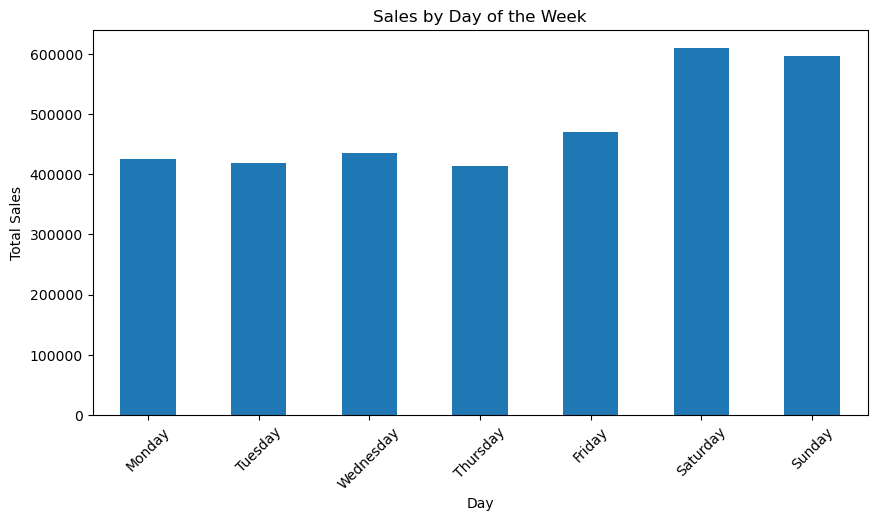

In [51]:
day_sales.plot(kind="bar", figsize=(10,5))

plt.title("Sales by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [52]:
best_day = day_sales.idxmax()
best_day_sales = day_sales.max()

worst_day = day_sales.idxmin()
worst_day_sales = day_sales.min()

print("Best Day:", best_day)
print("Best Day Sales:", best_day_sales)

print("Worst Day:", worst_day)
print("Worst Day Sales:", worst_day_sales)

Best Day: Saturday
Best Day Sales: 609259.8041
Worst Day: Thursday
Worst Day Sales: 413393.6427


In [54]:
item_analysis = df.groupby("Item Code").agg(
    Total_Sales=("Total", "sum"),
    Total_Quantity=("Quantity Sold (kilo)", "sum"),
    Average_Price=("Unit Selling Price (RMB/kg)", "mean")
)

In [55]:
item_analysis.sort_values("Total_Sales", ascending=False).head(10)

,Total_Sales,Total_Quantity,Average_Price
Item Code,,,
102900005116714,269874.2472,27537.228,9.900918
102900005116899,211652.1013,27149.440,7.952710
102900005116530,211198.3864,11920.227,17.985015
102900011016701,205113.6991,28164.331,7.378117
102900005115779,129756.9615,15910.461,8.209422
102900005116257,117729.4239,13602.001,8.678459
102900005117056,95568.6339,9703.125,9.857507
102900011000328,82009.3451,7792.181,10.658330
102900005115984,70665.1061,10305.364,6.892826


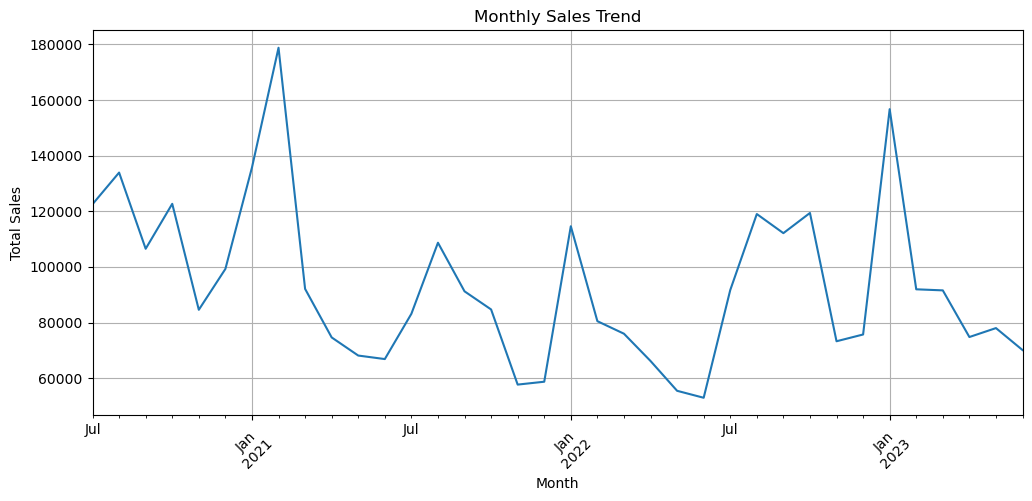

In [56]:
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [57]:
monthly_sales.sort_values(ascending=False).head(5)

Date
2021-02    178817.9040
2023-01    156731.8232
2021-01    135735.1150
2020-08    133930.3319
2020-10    122685.2828
Freq: M, Name: Total, dtype: float64

In [58]:
return_data = df[df["Sale or Return"] == "return"]

return_data["Quantity Sold (kilo)"].sum()

np.float64(-299.921)

In [59]:
return_data["Total"].sum()

np.float64(-2256.8655)

In [60]:
return_data = df[df["Sale or Return"] == "return"]

print("Total Returned Quantity:", return_data["Quantity Sold (kilo)"].sum())
print("Total Return Value:", return_data["Total"].sum())

Total Returned Quantity: -299.921
Total Return Value: -2256.8655


In [61]:
top_5_months = monthly_sales.sort_values(ascending=False).head(5)

print(top_5_months)

Date
2021-02    178817.9040
2023-01    156731.8232
2021-01    135735.1150
2020-08    133930.3319
2020-10    122685.2828
Freq: M, Name: Total, dtype: float64


In [62]:
best_day = day_sales.idxmax()
best_day_sales = day_sales.max()

worst_day = day_sales.idxmin()
worst_day_sales = day_sales.min()

print("Best Day:", best_day)
print("Best Day Sales:", best_day_sales)

print("Worst Day:", worst_day)
print("Worst Day Sales:", worst_day_sales)

Best Day: Saturday
Best Day Sales: 609259.8041
Worst Day: Thursday
Worst Day Sales: 413393.6427


In [63]:
top_10_quantity = (
    df.groupby("Item Code")["Quantity Sold (kilo)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_quantity)

Item Code
102900011016701    28164.331
102900005116714    27537.228
102900005116899    27149.440
102900005115960    19187.218
102900005115779    15910.461
106949711300259    15596.000
102900011030059    14325.000
102900005116257    13602.001
102900005116530    11920.227
102900011031100    10833.000
Name: Quantity Sold (kilo), dtype: float64


In [64]:
discount_avg = df.groupby("Discount (Yes/No)")["Total"].mean()

print(discount_avg)

Discount (Yes/No)
No     3.860552
Yes    3.401578
Name: Total, dtype: float64


In [65]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Rows: 878503
Columns: 10

Missing Values:
Date                           0
Time                           0
Item Code                      0
Quantity Sold (kilo)           0
Unit Selling Price (RMB/kg)    0
Sale or Return                 0
Discount (Yes/No)              0
Total                          0
Hour                           0
Day                            0
dtype: int64

Duplicate Rows: 0


In [66]:
total_sales = df["Total"].sum()
average_sales = df["Total"].mean()
total_quantity = df["Quantity Sold (kilo)"].sum()

print("Total Sales:", total_sales)
print("Average Transaction Value:", average_sales)
print("Total Quantity Sold (kg):", total_quantity)

Total Sales: 3369766.4768000003
Average Transaction Value: 3.8358053151782068
Total Quantity Sold (kg): 470975.91800000006


In [68]:
df.to_csv("cleaned_sales_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [69]:
print(df.columns.tolist())

['Date', 'Time', 'Item Code', 'Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)', 'Sale or Return', 'Discount (Yes/No)', 'Total', 'Hour', 'Day']


In [70]:
analysis_summary = {
    "Total Sales": df["Total"].sum(),
    "Average Transaction Value": df["Total"].mean(),
    "Total Quantity Sold (kg)": df["Quantity Sold (kilo)"].sum(),
    "Total Transactions": len(df)
}

analysis_summary

{'Total Sales': np.float64(3369766.4768000003),
 'Average Transaction Value': np.float64(3.8358053151782068),
 'Total Quantity Sold (kg)': np.float64(470975.91800000006),
 'Total Transactions': 878503}

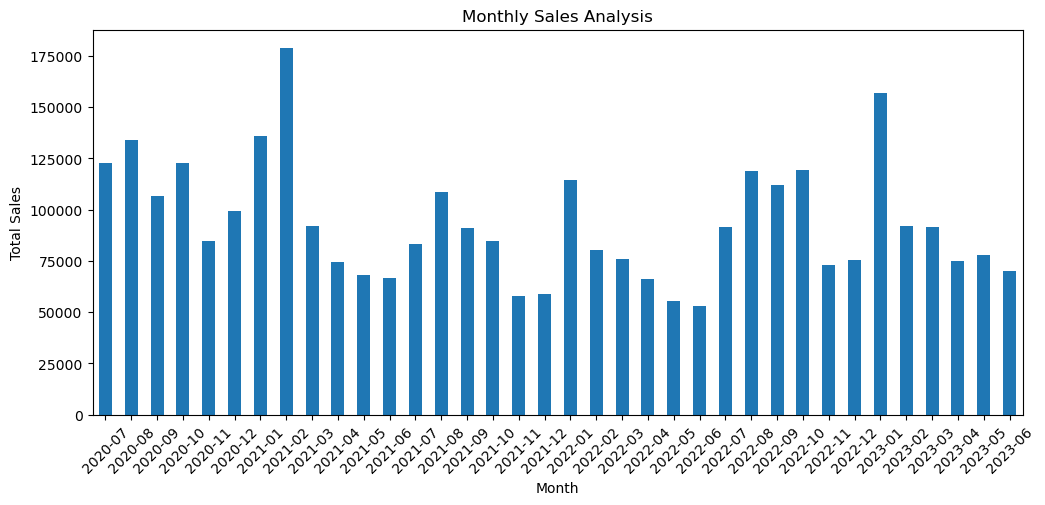

In [71]:
monthly_sales.plot(kind="bar", figsize=(12,5))

plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

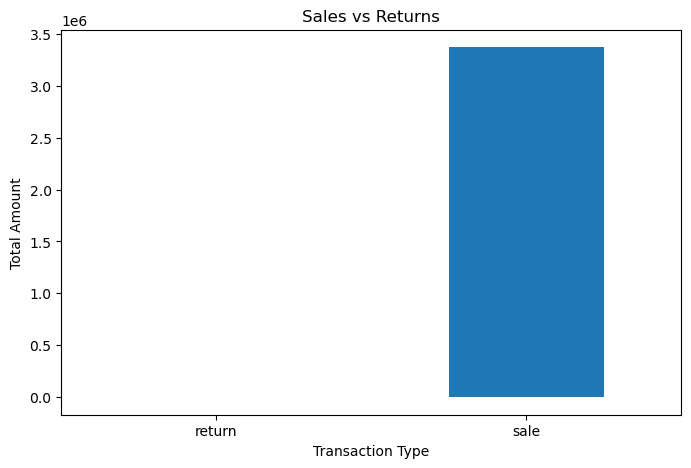

In [72]:
sales_by_type = df.groupby("Sale or Return")["Total"].sum()

sales_by_type.plot(kind="bar", figsize=(8,5))

plt.title("Sales vs Returns")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.show()

In [73]:
df.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Total,Hour,Day
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No,3.0096,9,Wednesday
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No,2.7168,9,Wednesday
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No,3.1084,9,Wednesday
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No,4.2100,9,Wednesday
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No,4.3120,9,Wednesday


In [74]:
print("Final Dataset Shape:", df.shape)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Final Dataset Shape: (878503, 10)
Total Rows: 878503
Total Columns: 10


In [75]:
df.dtypes

Date                           datetime64[ns]
Time                                   object
Item Code                               int64
Quantity Sold (kilo)                  float64
Unit Selling Price (RMB/kg)           float64
Sale or Return                         object
Discount (Yes/No)                      object
Total                                 float64
Hour                                    int64
Day                                    object
dtype: object

In [76]:
df.describe()

,Date,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Total,Hour
count,878503,8.785030e+05,878503.000000,878503.000000,878503.000000,878503.000000
mean,2021-11-20 20:11:55.407914752,1.030313e+14,0.536112,8.917144,3.835805,14.408807
min,2020-07-01 00:00:00,1.029000e+14,-9.082000,0.100000,-100.000000,8.000000
25%,2021-02-06 00:00:00,1.029000e+14,0.290000,4.900000,2.210000,11.000000
50%,2021-10-11 00:00:00,1.029000e+14,0.435000,7.900000,3.332000,15.000000
75%,2022-09-10 00:00:00,1.029000e+14,0.742000,10.800000,4.791600,18.000000
max,2023-06-30 00:00:00,1.069740e+14,160.000000,119.900000,944.000000,23.000000
std,NaN,7.174368e+11,0.400087,6.311265,2.813984,3.666489


In [77]:
top_item = df.groupby("Item Code")["Total"].sum().idxmax()
top_item_sales = df.groupby("Item Code")["Total"].sum().max()

print("Top Selling Item Code:", top_item)
print("Total Sales:", top_item_sales)

Top Selling Item Code: 102900005116714
Total Sales: 269874.2472


In [78]:
bottom_item = df.groupby("Item Code")["Total"].sum().idxmin()
bottom_item_sales = df.groupby("Item Code")["Total"].sum().min()

print("Lowest Selling Item Code:", bottom_item)
print("Total Sales:", bottom_item_sales)

Lowest Selling Item Code: 102900011031858
Total Sales: 3.5


In [80]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("Best Sales Month:", best_month)
print("Sales:", best_month_sales)

Best Sales Month: 2021-02
Sales: 178817.904


In [81]:
worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min()

print("Lowest Sales Month:", worst_month)
print("Sales:", worst_month_sales)

Lowest Sales Month: 2022-06
Sales: 52933.3625


In [82]:
transaction_counts = df["Sale or Return"].value_counts()

print(transaction_counts)

Sale or Return
sale      878042
return       461
Name: count, dtype: int64


In [83]:
discount_counts = df["Discount (Yes/No)"].value_counts()

print(discount_counts)

Discount (Yes/No)
No     831137
Yes     47366
Name: count, dtype: int64


In [84]:
hourly_sales.sort_values(ascending=False).head(10)

Hour
10    468435.9647
11    368073.0002
17    352750.6960
18    331021.0683
16    320312.6801
9     281576.2236
15    247113.3161
19    230216.0899
20    196319.3147
12    192757.2675
Name: Total, dtype: float64

In [85]:
best_hour = hourly_sales.idxmax()
best_hour_sales = hourly_sales.max()

print("Best Sales Hour:", best_hour)
print("Sales:", best_hour_sales)

Best Sales Hour: 10
Sales: 468435.9647


In [86]:
best_day = day_sales.idxmax()
best_day_sales = day_sales.max()

print("Best Sales Day:", best_day)
print("Sales:", best_day_sales)

Best Sales Day: Saturday
Sales: 609259.8041


In [87]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Average Transaction Value",
        "Total Quantity Sold (kg)",
        "Total Transactions",
        "Best Sales Month",
        "Best Sales Day",
        "Best Sales Hour"
    ],
    "Value": [
        df["Total"].sum(),
        df["Total"].mean(),
        df["Quantity Sold (kilo)"].sum(),
        len(df),
        best_month,
        best_day,
        best_hour
    ]
})

final_summary


,Metric,Value
0,Total Sales,3369766.4768
1,Average Transaction Value,3.835805
2,Total Quantity Sold (kg),470975.918
3,Total Transactions,878503
4,Best Sales Month,2021-02
5,Best Sales Day,Saturday
6,Best Sales Hour,10


In [88]:
final_summary.to_csv("sales_analysis_summary.csv", index=False)

print("Analysis summary saved successfully!")

Analysis summary saved successfully!


In [90]:
df.to_csv("final_sales_dataset.csv", index=False)

print("Mini project dataset saved successfully!")

Mini project dataset saved successfully!
